# TC3-3 — Fase 3: Análise Exploratória de Dados (EDA)

Este notebook consolida a análise exploratória da base `ml_aluno` para a Fase 3 do Tech Challenge.

Chamados contemplados:

- **TC3-43:** Analisar distribuição do target.
- **TC3-44:** Analisar distribuição das features.
- **TC3-45:** Analisar nulos, duplicidades e outliers.
- **TC3-46:** Analisar relações entre variáveis.
- **TC3-47:** Analisar diferenças por município, UF, rede e série.
- **TC3-48:** Analisar relações temporais.

A análise é descritiva e serve para orientar decisões posteriores de preparação dos dados, modelagem e interpretação.


## 1. Configuração e leitura da base

A base principal é a Feature Table `ml_aluno`, armazenada em `dados/principal/ml_aluno.zip` e extraída localmente para `dados/principal/ml_aluno/` quando necessário.


In [1]:
from pathlib import Path
import zipfile

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


def encontrar_raiz_projeto():
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "dados" / "principal" / "ml_aluno.zip").exists():
            return candidato
    raise FileNotFoundError(
        "Não foi possível encontrar dados/principal/ml_aluno.zip. "
        "Execute o notebook dentro do repositório ou confira se os dados foram baixados."
    )


PROJECT_ROOT = encontrar_raiz_projeto()
DADOS_PRINCIPAL = PROJECT_ROOT / "dados" / "principal"
ZIP_PATH = DADOS_PRINCIPAL / "ml_aluno.zip"
BASE_PATH = DADOS_PRINCIPAL / "ml_aluno"

if not BASE_PATH.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DADOS_PRINCIPAL)

arquivos = sorted(BASE_PATH.rglob("*.parquet"))
print(f"Arquivos parquet encontrados: {len(arquivos)}")

df = pd.concat([pd.read_parquet(arq) for arq in arquivos], ignore_index=True)

print(f"Registros: {len(df):,}")
print(f"Variáveis: {df.shape[1]}")
df.head()


Arquivos parquet encontrados: 69
Registros: 3,867,999
Variáveis: 19


,id_aluno,id_escola,id_municipio,nome_municipio,sigla_uf,ano_referencia,serie,rede,rede_descricao,caderno,presenca,preenchimento_caderno,proficiencia,peso_aluno,taxa_alfabetizacao_municipio_ano_anterior,media_portugues_municipio_ano_anterior,dataset_split,alfabetizado,processed_at
0,31062133,60021550,3136900,Juruaia,MG,2023,2,3,Municipal,6,1,1,731.235600,1.322718,NaN,NaN,treino,0,2026-09-01 18:03:53.794418
1,15078120,60001463,1506005,Prainha,PA,2023,2,3,Municipal,6,1,1,732.783236,1.324973,NaN,NaN,teste,0,2026-09-01 18:03:53.794418
2,43090743,60037407,4305108,Caxias do Sul,RS,2023,2,3,Municipal,6,1,1,755.341541,1.381868,NaN,NaN,treino,1,2026-09-01 18:03:53.794418
3,42097998,60035930,4219507,Xanxerê,SC,2023,2,3,Municipal,6,1,1,711.643712,2.012188,NaN,NaN,treino,0,2026-09-01 18:03:53.794418
4,43072338,60037775,4309209,Gravataí,RS,2023,2,3,Municipal,7,0,0,NaN,NaN,NaN,NaN,treino,0,2026-09-01 18:03:53.794418


## 2. Visão geral da base


In [2]:
resumo_geral = pd.DataFrame({
    "métrica": [
        "registros",
        "variáveis",
        "alunos únicos",
        "anos de referência",
        "municípios",
        "UFs",
        "escolas"
    ],
    "valor": [
        len(df),
        df.shape[1],
        df["id_aluno"].nunique(),
        df["ano_referencia"].nunique(),
        df["id_municipio"].nunique(),
        df["sigla_uf"].nunique(),
        df["id_escola"].nunique()
    ]
})

resumo_geral


,métrica,valor
0,registros,3867999
1,variáveis,19
2,alunos únicos,2352328
3,anos de referência,2
4,municípios,5548
5,UFs,26
6,escolas,42811


In [3]:
dicionario_eda = pd.DataFrame({
    "variavel": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "perc_nulos": (df.isna().mean() * 100).round(2).values,
    "valores_unicos": df.nunique(dropna=True).values
}).sort_values(["perc_nulos", "valores_unicos"], ascending=[False, False])

dicionario_eda


,variavel,tipo,nulos,perc_nulos,valores_unicos
15,media_portugues_municipio_ano_anterior,float64,1791646,46.32,6401
14,taxa_alfabetizacao_municipio_ano_anterior,float64,1791646,46.32,4061
12,proficiencia,float64,513338,13.27,1299544
13,peso_aluno,float64,513338,13.27,70528
0,id_aluno,str,0,0.00,2352328
1,id_escola,str,0,0.00,42811
2,id_municipio,str,0,0.00,5548
3,nome_municipio,str,0,0.00,5279
4,sigla_uf,str,0,0.00,26
9,caderno,str,0,0.00,22


## 3. TC3-43 — Distribuição do target

Análise da variável alvo `alfabetizado`, verificando volume e proporção das classes.


In [4]:
target = (
    df["alfabetizado"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("alfabetizado")
    .reset_index(name="quantidade")
)
target["percentual"] = (target["quantidade"] / target["quantidade"].sum() * 100).round(2)

target


,alfabetizado,quantidade,percentual
0,0,1883453,48.69
1,1,1984546,51.31


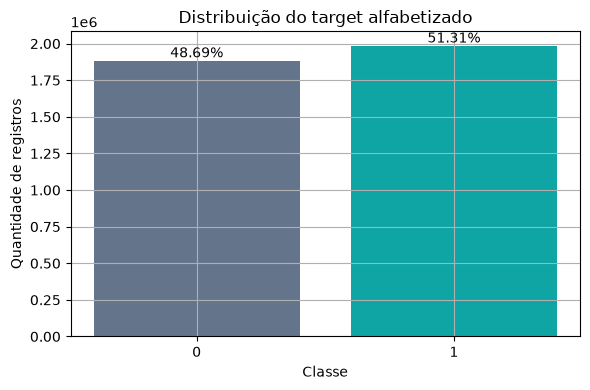

In [5]:
plt.figure(figsize=(6, 4))
plt.bar(target["alfabetizado"].astype(str), target["quantidade"], color=["#64748B", "#0EA5A4"])
plt.title("Distribuição do target alfabetizado")
plt.xlabel("Classe")
plt.ylabel("Quantidade de registros")
for i, row in target.iterrows():
    plt.text(i, row["quantidade"], f'{row["percentual"]}%', ha="center", va="bottom")
plt.tight_layout()
plt.show()


In [6]:
target_por_ano = (
    df.groupby(["ano_referencia", "alfabetizado"])
      .size()
      .rename("quantidade")
      .reset_index()
)
target_por_ano["percentual_no_ano"] = (
    target_por_ano["quantidade"]
    / target_por_ano.groupby("ano_referencia")["quantidade"].transform("sum")
    * 100
).round(2)

target_por_ano


,ano_referencia,alfabetizado,quantidade,percentual_no_ano
0,2023,0,870012,49.79
1,2023,1,877427,50.21
2,2024,0,1013441,47.79
3,2024,1,1107119,52.21


## 4. TC3-44 — Distribuição das features

Análise descritiva das variáveis numéricas e categóricas candidatas.


In [7]:
variaveis_numericas = [
    "ano_referencia",
    "serie",
    "rede",
    "presenca",
    "preenchimento_caderno",
    "proficiencia",
    "peso_aluno",
    "taxa_alfabetizacao_municipio_ano_anterior",
    "media_portugues_municipio_ano_anterior"
]

variaveis_numericas = [col for col in variaveis_numericas if col in df.columns]

df[variaveis_numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
ano_referencia,3867999.0,2023.548232,0.497668,2023.000000,2023.000000,2024.000000,2024.000000,2024.000000
serie,3867999.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000
rede,3867999.0,2.887442,0.316072,2.000000,3.000000,3.000000,3.000000,4.000000
presenca,3867999.0,0.867592,0.338934,0.000000,1.000000,1.000000,1.000000,1.000000
preenchimento_caderno,3867999.0,0.867286,0.339266,0.000000,1.000000,1.000000,1.000000,1.000000
proficiencia,3354661.0,748.379854,47.585975,578.460000,719.768570,753.150000,779.650000,904.382031
peso_aluno,3354661.0,1.148490,0.358516,0.095238,1.000709,1.091625,1.208405,142.545400
taxa_alfabetizacao_municipio_ano_anterior,2076353.0,56.315463,15.331532,3.410000,46.570000,55.660000,65.790000,100.000000
media_portugues_municipio_ano_anterior,2076353.0,745.047354,19.602551,673.298300,733.705700,742.870700,753.162700,868.455400


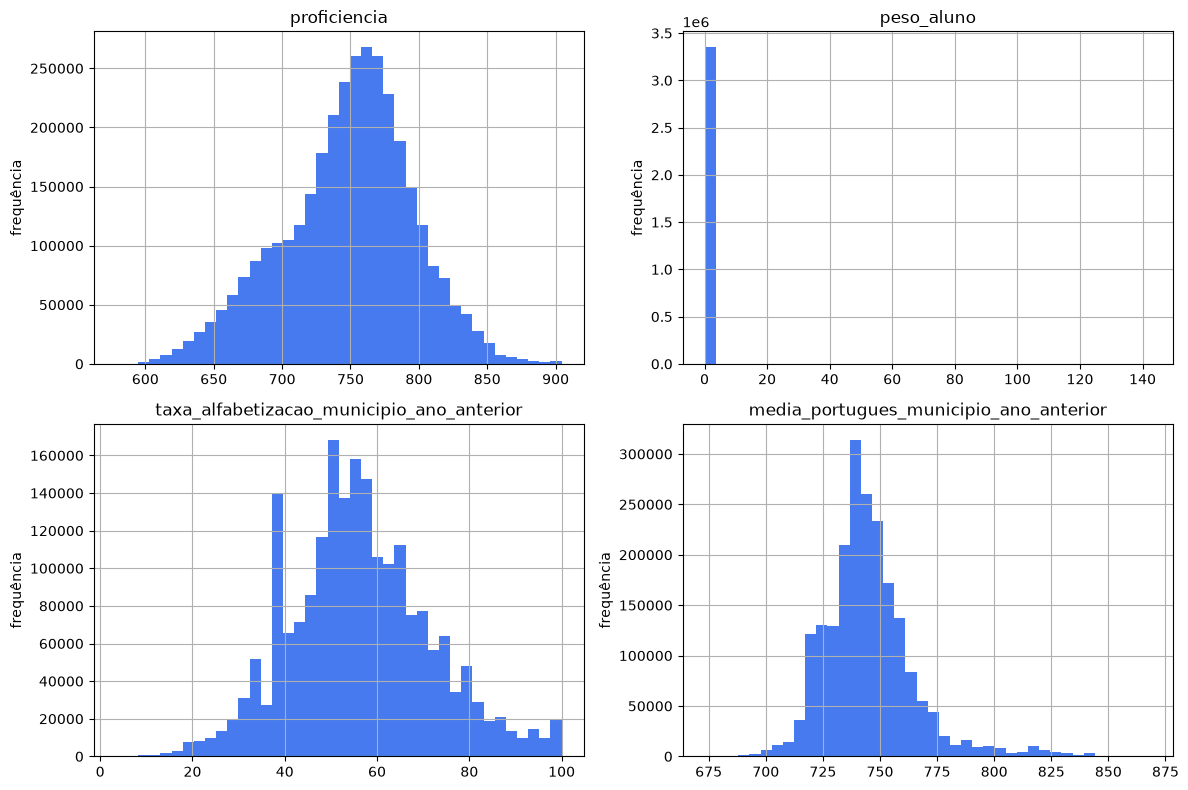

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols_hist = [
    "proficiencia",
    "peso_aluno",
    "taxa_alfabetizacao_municipio_ano_anterior",
    "media_portugues_municipio_ano_anterior"
]
for ax, col in zip(axes.ravel(), cols_hist):
    serie = df[col].dropna()
    ax.hist(serie, bins=40, color="#2563EB", alpha=0.85)
    ax.set_title(col)
    ax.set_ylabel("frequência")
plt.tight_layout()
plt.show()


In [9]:
categoricas_resumo = {}
for col in ["sigla_uf", "rede_descricao", "serie", "dataset_split"]:
    categoricas_resumo[col] = (
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="quantidade")
        .assign(percentual=lambda x: (x["quantidade"] / len(df) * 100).round(2))
        .head(15)
    )

categoricas_resumo["sigla_uf"]


,sigla_uf,quantidade,percentual
0,SP,443777,11.47
1,MG,413557,10.69
2,RJ,311198,8.05
3,PR,277446,7.17
4,BA,253300,6.55
5,RS,229410,5.93
6,PA,204949,5.30
7,SC,201171,5.20
8,CE,190190,4.92
9,PE,168630,4.36


In [10]:
categoricas_resumo["rede_descricao"]


,rede_descricao,quantidade,percentual
0,Municipal,3432576,88.74
1,Estadual,435398,11.26
2,Privada,25,0.00


In [11]:
categoricas_resumo["serie"]


,serie,quantidade,percentual
0,2,3867999,100.0


In [12]:
categoricas_resumo["dataset_split"]


,dataset_split,quantidade,percentual
0,treino,2705252,69.94
1,teste,581596,15.04
2,validacao,581151,15.02


## 5. TC3-45 — Nulos, duplicidades e outliers

Verificação de qualidade dos dados, incluindo ausência de valores, repetição de alunos em anos diferentes e pontos extremos em variáveis numéricas.


In [13]:
nulos = (
    dicionario_eda[dicionario_eda["nulos"] > 0]
    .sort_values("perc_nulos", ascending=False)
    .reset_index(drop=True)
)

nulos


,variavel,tipo,nulos,perc_nulos,valores_unicos
0,media_portugues_municipio_ano_anterior,float64,1791646,46.32,6401
1,taxa_alfabetizacao_municipio_ano_anterior,float64,1791646,46.32,4061
2,proficiencia,float64,513338,13.27,1299544
3,peso_aluno,float64,513338,13.27,70528


In [14]:
duplicidade_aluno = pd.DataFrame({
    "métrica": ["registros", "id_aluno únicos", "registros duplicados por id_aluno"],
    "valor": [len(df), df["id_aluno"].nunique(), df["id_aluno"].duplicated().sum()]
})

distribuicao_registros_por_aluno = (
    df.groupby("id_aluno")
      .size()
      .value_counts()
      .sort_index()
      .rename_axis("registros_por_aluno")
      .reset_index(name="quantidade_alunos")
)

duplicidade_aluno


,métrica,valor
0,registros,3867999
1,id_aluno únicos,2352328
2,registros duplicados por id_aluno,1515671


In [15]:
distribuicao_registros_por_aluno


,registros_por_aluno,quantidade_alunos
0,1,836657
1,2,1515671


In [16]:
outliers_resumo = []
for col in ["proficiencia", "peso_aluno", "taxa_alfabetizacao_municipio_ano_anterior", "media_portugues_municipio_ano_anterior"]:
    serie = df[col].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    qtd_outliers = ((serie < limite_inferior) | (serie > limite_superior)).sum()
    outliers_resumo.append({
        "variavel": col,
        "q1": round(q1, 4),
        "q3": round(q3, 4),
        "limite_inferior": round(limite_inferior, 4),
        "limite_superior": round(limite_superior, 4),
        "qtd_outliers_iqr": int(qtd_outliers),
        "perc_outliers_iqr": round(qtd_outliers / len(serie) * 100, 2)
    })

outliers_resumo = pd.DataFrame(outliers_resumo)
outliers_resumo


,variavel,q1,q3,limite_inferior,limite_superior,qtd_outliers_iqr,perc_outliers_iqr
0,proficiencia,719.7686,779.6500,629.9464,869.4721,42761,1.27
1,peso_aluno,1.0007,1.2084,0.6892,1.5199,174136,5.19
2,taxa_alfabetizacao_municipio_ano_anterior,46.5700,65.7900,17.7400,94.6200,37654,1.81
3,media_portugues_municipio_ano_anterior,733.7057,753.1627,704.5202,782.3482,101809,4.90


C:\Users\Usuario\AppData\Local\Temp\ipykernel_35320\1566993475.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_35320\1566993475.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_35320\1566993475.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_35320\1566993475.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'v

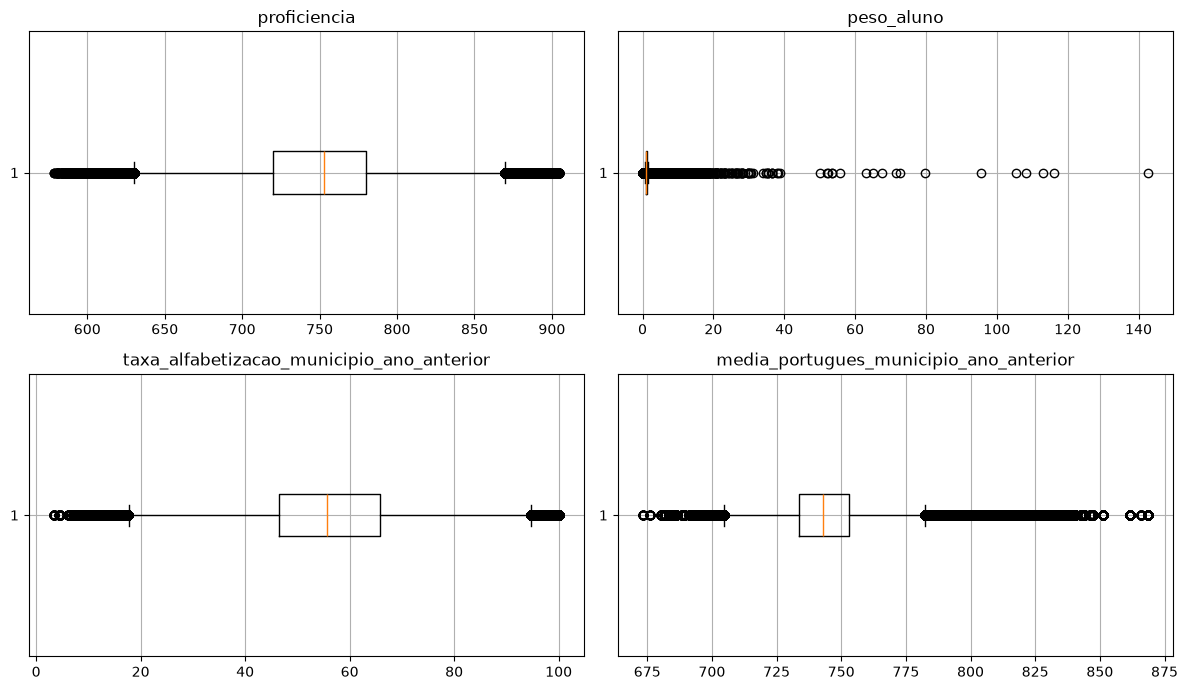

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.ravel(), ["proficiencia", "peso_aluno", "taxa_alfabetizacao_municipio_ano_anterior", "media_portugues_municipio_ano_anterior"]):
    ax.boxplot(df[col].dropna(), vert=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 6. TC3-46 — Relações entre variáveis

Análise de associações entre features numéricas, categorias principais e target.


In [18]:
correlacoes = df[
    [
        "alfabetizado",
        "ano_referencia",
        "serie",
        "rede",
        "presenca",
        "preenchimento_caderno",
        "proficiencia",
        "peso_aluno",
        "taxa_alfabetizacao_municipio_ano_anterior",
        "media_portugues_municipio_ano_anterior"
    ]
].corr(numeric_only=True).round(3)

correlacoes


,alfabetizado,ano_referencia,serie,rede,presenca,preenchimento_caderno,proficiencia,peso_aluno,taxa_alfabetizacao_municipio_ano_anterior,media_portugues_municipio_ano_anterior
alfabetizado,1.000,0.020,NaN,-0.013,0.401,0.402,0.796,-0.049,0.236,0.247
ano_referencia,0.020,1.000,NaN,-0.068,0.020,0.019,0.015,-0.030,NaN,NaN
serie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rede,-0.013,-0.068,NaN,1.000,0.012,0.012,-0.021,-0.021,-0.028,-0.018
presenca,0.401,0.020,NaN,0.012,1.000,0.999,NaN,NaN,0.055,0.074
preenchimento_caderno,0.402,0.019,NaN,0.012,0.999,1.000,NaN,NaN,0.055,0.074
proficiencia,0.796,0.015,NaN,-0.021,NaN,NaN,1.000,-0.067,0.307,0.341
peso_aluno,-0.049,-0.030,NaN,-0.021,NaN,NaN,-0.067,1.000,-0.072,-0.120
taxa_alfabetizacao_municipio_ano_anterior,0.236,NaN,NaN,-0.028,0.055,0.055,0.307,-0.072,1.000,0.941
media_portugues_municipio_ano_anterior,0.247,NaN,NaN,-0.018,0.074,0.074,0.341,-0.120,0.941,1.000


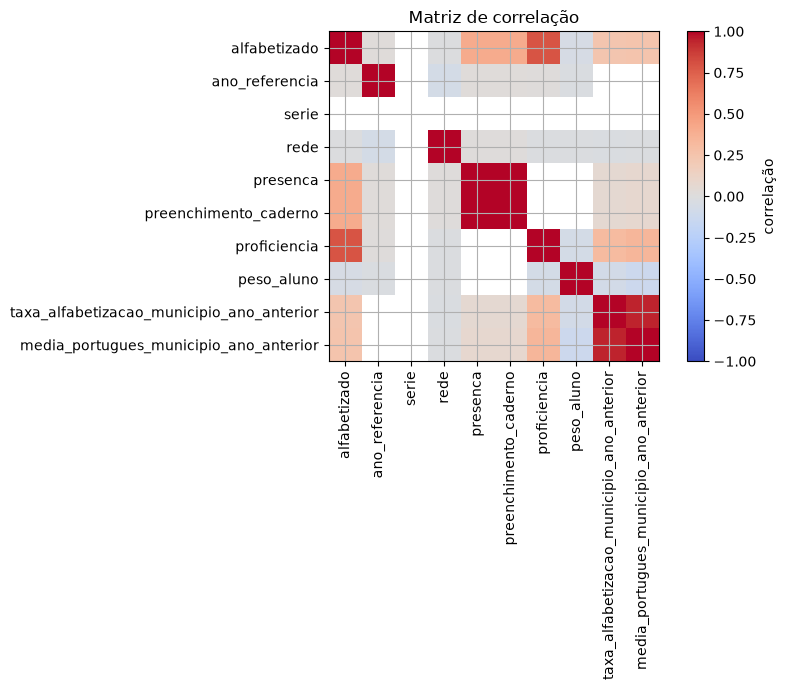

In [19]:
plt.figure(figsize=(9, 7))
plt.imshow(correlacoes, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="correlação")
plt.xticks(range(len(correlacoes.columns)), correlacoes.columns, rotation=90)
plt.yticks(range(len(correlacoes.index)), correlacoes.index)
plt.title("Matriz de correlação")
plt.tight_layout()
plt.show()


In [20]:
target_por_rede_serie = (
    df.groupby(["rede_descricao", "serie"])
      .agg(
          registros=("alfabetizado", "size"),
          taxa_alfabetizado=("alfabetizado", "mean")
      )
      .reset_index()
)
target_por_rede_serie["taxa_alfabetizado"] = (target_por_rede_serie["taxa_alfabetizado"] * 100).round(2)

target_por_rede_serie.sort_values(["rede_descricao", "serie"])


,rede_descricao,serie,registros,taxa_alfabetizado
0,Estadual,2,435398,53.15
1,Municipal,2,3432576,51.07
2,Privada,2,25,64.00


## 7. TC3-47 — Diferenças por município, UF, rede e série

Comparação de volume e taxa de alfabetização por recortes territoriais e educacionais.


In [21]:
eda_uf = (
    df.groupby("sigla_uf")
      .agg(
          registros=("alfabetizado", "size"),
          taxa_alfabetizado=("alfabetizado", "mean"),
          municipios=("id_municipio", "nunique"),
          escolas=("id_escola", "nunique")
      )
      .reset_index()
)
eda_uf["taxa_alfabetizado"] = (eda_uf["taxa_alfabetizado"] * 100).round(2)

eda_uf.sort_values("taxa_alfabetizado", ascending=False)


,sigla_uf,registros,taxa_alfabetizado,municipios,escolas
5,CE,190190,82.11,184,2447
7,ES,98020,62.57,78,1304
8,GO,160907,62.47,246,1958
17,PR,277446,62.26,399,2988
10,MG,413557,59.44,853,4639
20,RO,45507,56.58,52,400
15,PE,168630,55.98,185,2185
16,PI,68207,53.26,224,1045
9,MA,144242,52.64,217,2113
24,SP,443777,52.18,642,6071


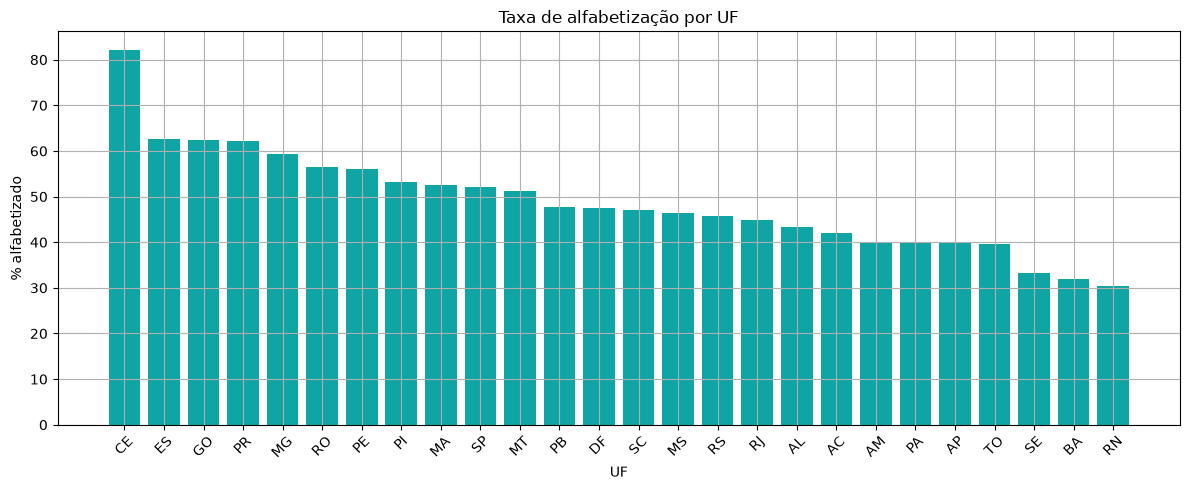

In [22]:
plt.figure(figsize=(12, 5))
eda_uf_plot = eda_uf.sort_values("taxa_alfabetizado", ascending=False)
plt.bar(eda_uf_plot["sigla_uf"], eda_uf_plot["taxa_alfabetizado"], color="#0EA5A4")
plt.title("Taxa de alfabetização por UF")
plt.xlabel("UF")
plt.ylabel("% alfabetizado")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [23]:
eda_municipio = (
    df.groupby(["id_municipio", "nome_municipio", "sigla_uf"])
      .agg(
          registros=("alfabetizado", "size"),
          taxa_alfabetizado=("alfabetizado", "mean"),
          escolas=("id_escola", "nunique")
      )
      .reset_index()
)
eda_municipio["taxa_alfabetizado"] = (eda_municipio["taxa_alfabetizado"] * 100).round(2)

eda_municipio.query("registros >= 1000").sort_values("taxa_alfabetizado", ascending=False).head(20)


,id_municipio,nome_municipio,sigla_uf,registros,taxa_alfabetizado,escolas
943,2305001,Guaraciaba do Norte,CE,1232,97.00,34
1042,2312908,Sobral,CE,4936,95.73,69
1026,2311405,Quixeramobim,CE,1928,95.38,54
1036,2312304,São Benedito,CE,1177,95.07,37
928,2304251,Cruz,CE,1028,94.94,24
646,2112704,Vargem Grande,MA,1227,94.62,24
939,2304707,Granja,CE,1443,94.59,37
909,2302800,Canindé,CE,1772,94.53,39
1008,2310209,Paracuru,CE,1146,94.07,30
925,2304103,Crateús,CE,1585,93.56,56


In [24]:
eda_rede = (
    df.groupby("rede_descricao")
      .agg(registros=("alfabetizado", "size"), taxa_alfabetizado=("alfabetizado", "mean"))
      .reset_index()
)
eda_rede["taxa_alfabetizado"] = (eda_rede["taxa_alfabetizado"] * 100).round(2)

eda_rede.sort_values("taxa_alfabetizado", ascending=False)


,rede_descricao,registros,taxa_alfabetizado
2,Privada,25,64.00
0,Estadual,435398,53.15
1,Municipal,3432576,51.07


In [25]:
eda_serie = (
    df.groupby("serie")
      .agg(registros=("alfabetizado", "size"), taxa_alfabetizado=("alfabetizado", "mean"))
      .reset_index()
)
eda_serie["taxa_alfabetizado"] = (eda_serie["taxa_alfabetizado"] * 100).round(2)

eda_serie.sort_values("serie")


,serie,registros,taxa_alfabetizado
0,2,3867999,51.31


## 8. TC3-48 — Relações temporais

Análise das diferenças entre anos de referência e da evolução dos principais indicadores.


In [26]:
eda_temporal = (
    df.groupby("ano_referencia")
      .agg(
          registros=("alfabetizado", "size"),
          taxa_alfabetizado=("alfabetizado", "mean"),
          alunos=("id_aluno", "nunique"),
          escolas=("id_escola", "nunique"),
          municipios=("id_municipio", "nunique"),
          media_proficiencia=("proficiencia", "mean")
      )
      .reset_index()
)
eda_temporal["taxa_alfabetizado"] = (eda_temporal["taxa_alfabetizado"] * 100).round(2)
eda_temporal["media_proficiencia"] = eda_temporal["media_proficiencia"].round(2)

eda_temporal


,ano_referencia,registros,taxa_alfabetizado,alunos,escolas,municipios,media_proficiencia
0,2023,1747439,50.21,1747439,36776,4873,747.56
1,2024,2120560,52.21,2120560,42497,5519,749.04


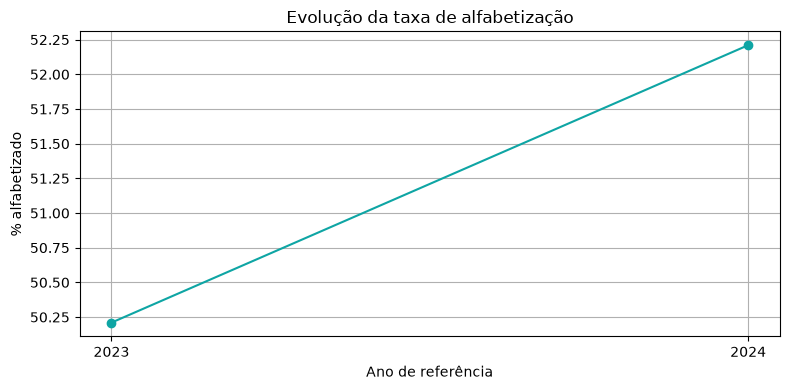

In [27]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(eda_temporal["ano_referencia"], eda_temporal["taxa_alfabetizado"], marker="o", color="#0EA5A4")
ax1.set_ylabel("% alfabetizado")
ax1.set_xlabel("Ano de referência")
ax1.set_title("Evolução da taxa de alfabetização")
ax1.set_xticks(eda_temporal["ano_referencia"])
plt.tight_layout()
plt.show()


In [28]:
temporal_por_uf = (
    df.groupby(["ano_referencia", "sigla_uf"])
      .agg(registros=("alfabetizado", "size"), taxa_alfabetizado=("alfabetizado", "mean"))
      .reset_index()
)
temporal_por_uf["taxa_alfabetizado"] = (temporal_por_uf["taxa_alfabetizado"] * 100).round(2)

temporal_por_uf_pivot = temporal_por_uf.pivot(index="sigla_uf", columns="ano_referencia", values="taxa_alfabetizado")
if {2023, 2024}.issubset(set(temporal_por_uf_pivot.columns)):
    temporal_por_uf_pivot["delta_2024_2023"] = (temporal_por_uf_pivot[2024] - temporal_por_uf_pivot[2023]).round(2)

temporal_por_uf_pivot.sort_values("delta_2024_2023", ascending=False).head(15)


ano_referencia,2023,2024,delta_2024_2023
sigla_uf,,,
MG,54.55,64.50,9.95
MS,42.01,50.88,8.87
GO,58.30,67.00,8.70
PI,49.65,57.17,7.52
TO,36.68,42.70,6.02
MT,48.60,53.94,5.34
AP,37.32,42.15,4.83
AL,41.08,45.90,4.82
PB,45.44,49.98,4.54


## 9. Síntese da EDA

Principais encaminhamentos para as próximas fases:

- O target está relativamente balanceado, o que favorece comparação de modelos sem necessidade imediata de reamostragem agressiva.
- As variáveis de desempenho e avaliação precisam ser analisadas com cuidado por risco de Data Leakage.
- Há nulos relevantes em indicadores municipais de ano anterior, `peso_aluno` e `proficiencia`, exigindo estratégia de imputação ou decisão de exclusão.
- Recortes por UF, rede, município e série apresentam diferenças relevantes e devem orientar análise de fairness, segmentação e interpretação.
- A dimensão temporal entre 2023 e 2024 deve ser preservada no desenho de validação e na leitura dos resultados.
